# Example evaluation notebook for the flopsmeter

## Floating points operation performance measurements for AMD Ryzen 7 9800X3D

- Base Clock: 4.7 Ghz
- 8 core
- Multithreading support (HT) 2 threads for each core.
- L2 cache: 8 MB
- L3 cache: 96 MB


This program performs a matrix multiplication and measures the elapsed time. This is how we get the operation speed (Gflops).

Since it is faster to calculate with smaller numbers, we also performed the measurement for fp32, fp64, and fp80 numbers.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['figure.figsize'] = [12, 7]
print("Python version:", sys.version)
print("Numpy version:", np.version.full_version)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

Python version: 3.12.7 (main, Oct 15 2024, 17:58:55) [GCC 10.2.1 20210110]
Numpy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.9.2


In [2]:
data1 = pd.read_json("data/flopsmeter_output_20250509_ryzen9800x3d.log", orient="records", lines=True)
data2 = pd.read_json("data/flopsmeter_output_20250509_htoff_ryzen9800x3d.log", orient="records", lines=True)
data1

,timestamp,n_X,n_Y,n_Z,dtype,threadcount,device_type,device,time_init,time_matmul,Gflops
0,2025-05-09 10:58:56,1000,1000,1000,fp80,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.013143,0.202732,9.860327
1,2025-05-09 10:58:56,1000,1000,1000,fp64,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.006205,0.010009,199.724901
2,2025-05-09 10:58:56,1000,1000,1000,fp32,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.006265,0.004395,454.831107
3,2025-05-09 10:59:00,2651,2651,2651,fp80,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.082016,3.688087,10.101273
4,2025-05-09 10:59:00,2651,2651,2651,fp64,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.042571,0.209491,177.833125
...,...,...,...,...,...,...,...,...,...,...,...
85,2025-05-09 11:28:23,7907,7907,7907,fp64,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.376022,14.263792,69.311095
86,2025-05-09 11:28:30,7907,7907,7907,fp32,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.369907,6.429576,153.764266
87,2025-05-09 11:30:21,8000,8000,8000,fp80,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.725855,110.413544,9.273645
88,2025-05-09 11:30:36,8000,8000,8000,fp64,16,pthread-cpu,AMD Ryzen 7 9800X3D 8-Core Processor,0.381626,14.248126,71.864608


In [3]:
#calculate the memory footprint for the test-data. M1 matrix is (X,Y), M2 matrix is (Y,Z) so the output matrix is (X,Z)
data1['datasize'] = data1['n_X']*data1['n_Y'] + data1['n_Y']*data1['n_Z'] + data1['n_X']*data1['n_Z']
data1.loc[data1['dtype'] == "fp80", 'datasize'] *= 10
data1.loc[data1['dtype'] == "fp64", 'datasize'] *= 8
data1.loc[data1['dtype'] == "fp32", 'datasize'] *= 4
data1['datasize'] /= 1048576 # MiBytes

data2['datasize'] = data2['n_X']*data2['n_Y'] + data2['n_Y']*data2['n_Z'] + data2['n_X']*data2['n_Z']
data2.loc[data2['dtype'] == "fp80", 'datasize'] *= 10
data2.loc[data2['dtype'] == "fp64", 'datasize'] *= 8
data2.loc[data2['dtype'] == "fp32", 'datasize'] *= 4
data2['datasize'] /= 1048576 # MiBytes

## Is multithreading worth it?

I compare the measurement taken with the HT turned off with the measurement taken with the HT turned on.

Worth it.

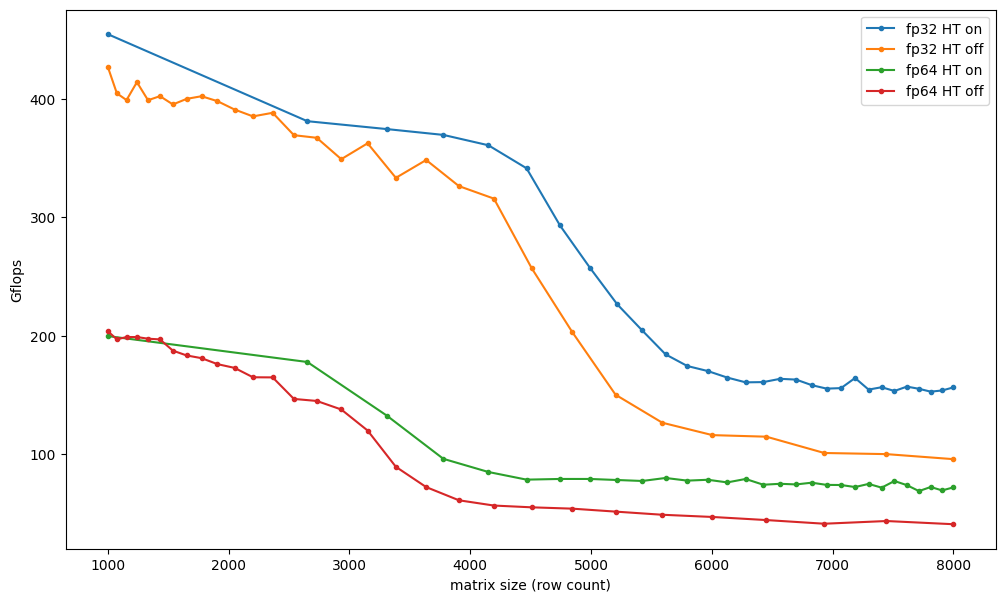

In [4]:
for dtype in ("fp32", "fp64"):
    subdata = data1.query(f'dtype=="{dtype}"').sort_values(by="n_X")
    plt.plot(subdata["n_X"], subdata["Gflops"], ".-", label=f"{dtype} HT on")
    subdata = data2.query(f'dtype=="{dtype}"').sort_values(by="n_X")
    plt.plot(subdata["n_X"], subdata["Gflops"], ".-", label=f"{dtype} HT off")

plt.ylabel("Gflops")
#plt.yscale("log")
plt.xlabel("matrix size (row count)")
plt.legend()
None

## How the cache works?

It can be seen that performance drops significantly when the L3 cache size is exceeded. It seems that this task is limited more by memory speed than by the CPU.

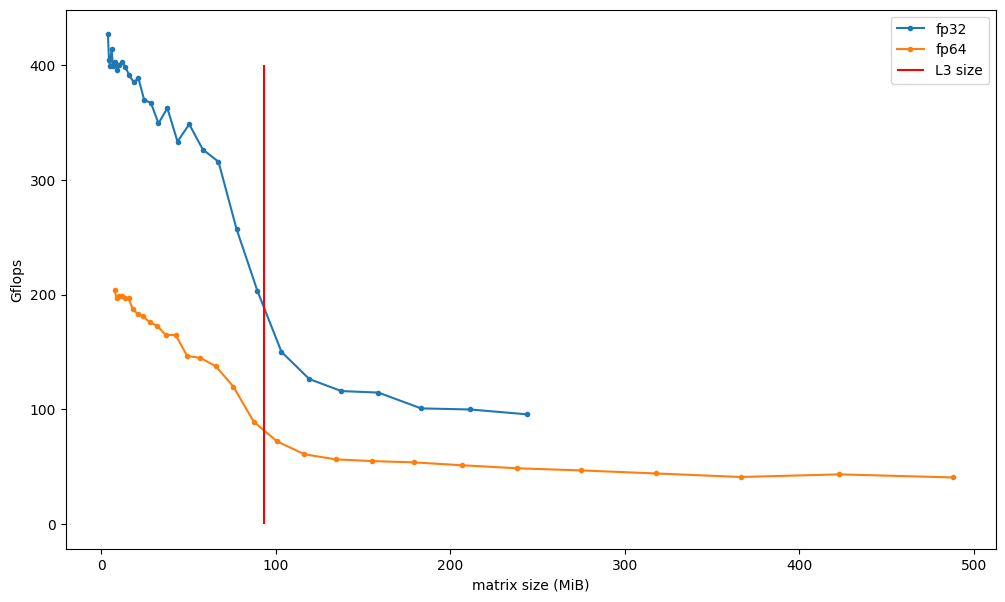

In [5]:
for dtype in ("fp32", "fp64"):
    subdata = data2.query(f'dtype=="{dtype}"').sort_values(by="datasize")
    plt.plot(subdata["datasize"]/3, subdata["Gflops"], ".-", label=f"{dtype}")

plt.ylabel("Gflops")
#plt.yscale("log")
plt.xlabel("matrix size (MiB)")
plt.vlines(93, ymin=0, ymax=400, color="r", label="L3 size")

plt.legend()
None

## fp80 and fp64 speed comparison

The fp80 data type is 10 Bytes long. The fp64 is 8 bytes long.  Not much difference. However, it calculates much, much slower with the fp80 data type. This high ratio suggests that there is no real fp80 computing hardware, but rather it is emulated in software.

In contrast, fp32 is only twice as fast as fp64, which is perfectly fine. In the middle, the increase indicates that at this size, an fp32 matrix still fits in the cache, but an fp64 matrix no longer does.


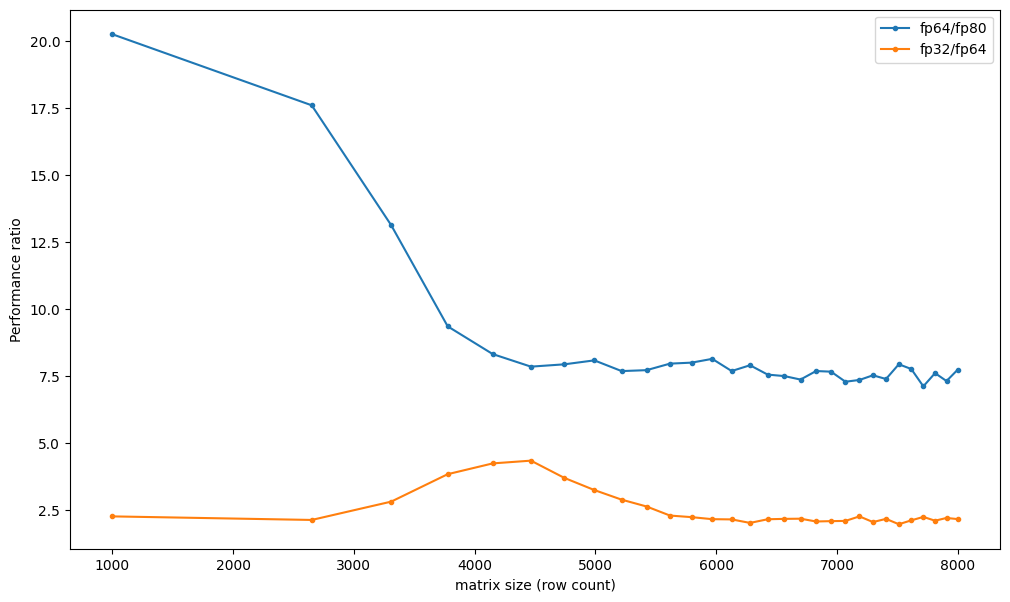

In [6]:
subdata_fp80 = data1.query('dtype=="fp80"').sort_values(by="n_X", ignore_index=True)
subdata_fp64 = data1.query('dtype=="fp64"').sort_values(by="n_X", ignore_index=True)
subdata_fp32 = data1.query('dtype=="fp32"').sort_values(by="n_X", ignore_index=True)

plt.plot(subdata_fp80["n_X"], subdata_fp64["Gflops"]/subdata_fp80["Gflops"], ".-", label="fp64/fp80")
plt.plot(subdata_fp64["n_X"], subdata_fp32["Gflops"]/subdata_fp64["Gflops"], ".-", label="fp32/fp64")

plt.ylabel("Performance ratio")
#plt.yscale("log")
plt.xlabel("matrix size (row count)")
plt.legend()
None